# Huấn luyện và Đánh giá Mô hình Fraud Detection

Notebook này hỗ trợ chạy dự án phát hiện gian lận (Fraud Detection) với Graph Neural Networks trực tiếp từng bước mà không cần gọi script `train.py` và `visualize.py`.

In [1]:
import os
import torch
from omegaconf import OmegaConf

from fraud_detection import Trainer, GAT, GCN, GIN, EllipticDataset

c:\Users\Tuan\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\Tuan\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch_scatter\_version_cpu.pyd
  import torch_geometric.typing
c:\Users\Tuan\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\Tuan\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch_sparse\_version_cpu.pyd
  import torch_geometric.typing


## 1. Đọc Cấu hình (Config)
Bạn có thể đổi sang các config khác nằm trong thư mục `configs/` như `elliptic_gcn.yaml`, `elliptic_gin.yaml`, ...

In [2]:
config_path = "configs/elliptic_gcn.yaml"
config = OmegaConf.load(config_path)

print("=== Cấu Hình Đã Tải ===")
print(OmegaConf.to_yaml(config))

=== Cấu Hình Đã Tải ===
name: elliptic_gcn
dataset:
  features_path: data/elliptic/elliptic_txs_features.csv
  edges_path: data/elliptic/elliptic_txs_edgelist.csv
  classes: data/elliptic/elliptic_txs_classes.csv
model:
  input_dim: ???
  hidden_dim: 128
  output_dim: 1
train:
  dataset: elliptic
  model: gcn
  num_epochs: 100
  device: cpu
  lr: 0.01
  weight_decay: 1.0e-05
  print_freq: 10
  save_dir: weights/
  save_freq: 100



## 2. Huấn luyện (Training)
Khởi tạo `Trainer` bằng bộ config và tiến hành bắt đầu quá trình huấn luyện.

In [3]:
trainer = Trainer(config)

# Bắt đầu huấn luyện
trainer.train()

# Lưu trọng số của mô hình
trainer.save(config.name)
print(f"\nTrọng số mô hình đã được lưu tại: weights/{config.name}.pt")

epoch: 10: 
Train results: {'accuracy': 0.8886064093129056, 'f1_micro': 0.8886064093129056, 'f1_macro': 0.7422601153052208, 'recall': 0.5831889081455806, 'precision': 0.5168970814132104}
Evaluation results: {'accuracy': 0.6456508698260348, 'f1_micro': 0.6456508698260348, 'f1_macro': 0.49863237509732006, 'recall': 0.801477377654663, 'precision': 0.1323170731707317}
epoch: 20: 
Train results: {'accuracy': 0.9174081755536228, 'f1_micro': 0.9174081755536228, 'f1_macro': 0.7767348533532725, 'recall': 0.5337954939341422, 'precision': 0.683684794672586}
Evaluation results: {'accuracy': 0.6947210557888422, 'f1_micro': 0.6947210557888422, 'f1_macro': 0.523162526007201, 'recall': 0.7303785780240074, 'precision': 0.1415533285612026}
epoch: 30: 
Train results: {'accuracy': 0.9380477687830334, 'f1_micro': 0.9380477687830334, 'f1_macro': 0.8350100098981439, 'recall': 0.6380704794916233, 'precision': 0.7866809116809117}
Evaluation results: {'accuracy': 0.7367126574685063, 'f1_micro': 0.73671265746850

## 3. Trực quan hóa (Visualization)
Vẽ đồ thị đưa ra những dự đoán của mô hình tại một bước thời gian (`time_step`) cụ thể. Hình vẽ ban đầu sẽ được lưu trong thư mục `visualizations/` và được hiển thị ngay bên dưới.

Graph visualization saved to `visualizations/elliptic_gcn/30.png`

Ảnh kết quả đã được vẽ và lưu tại visualizations/elliptic_gcn/30.png


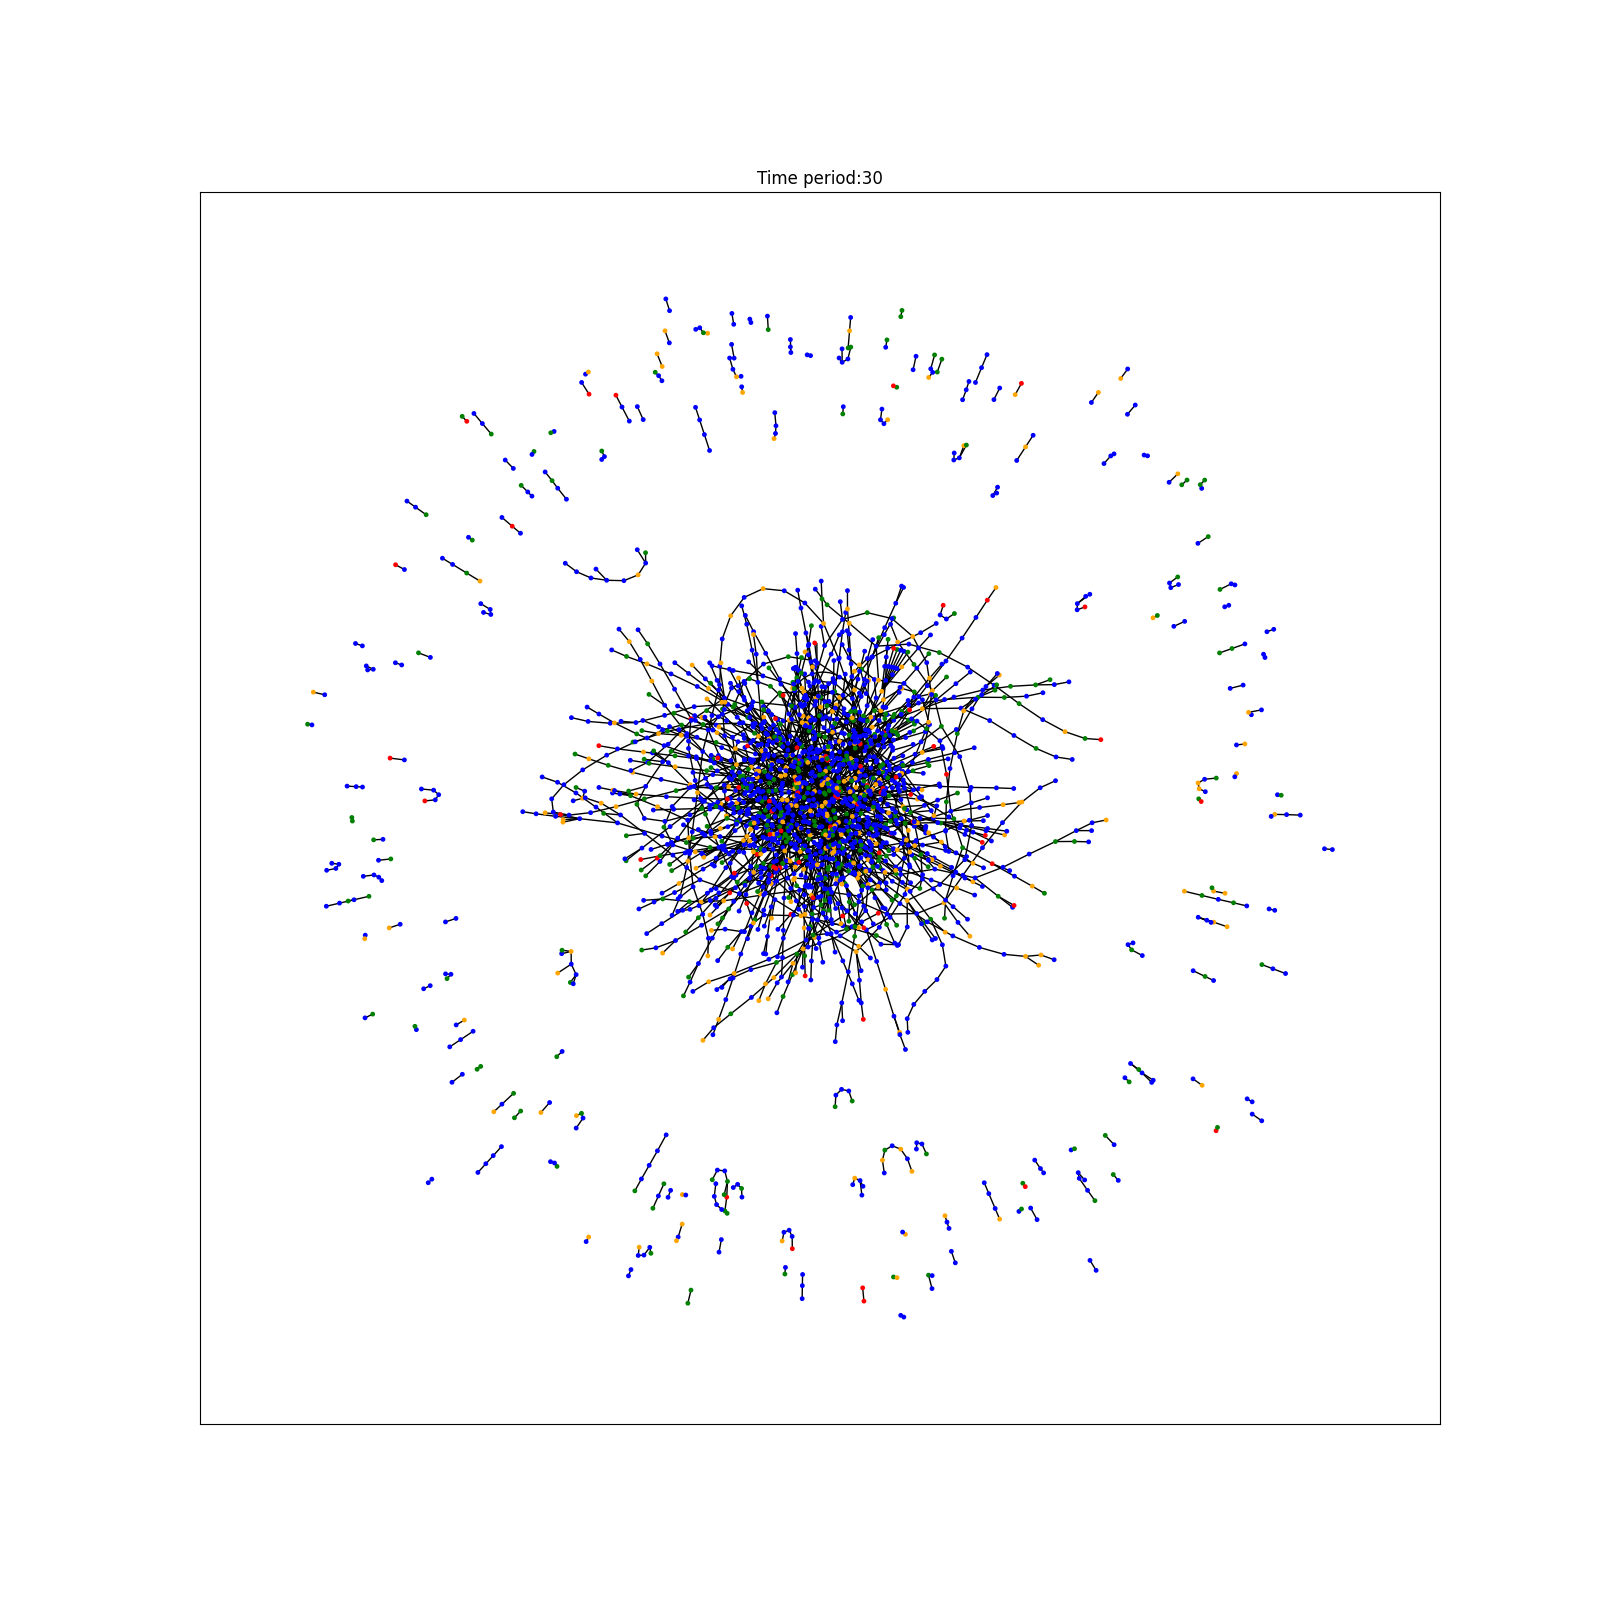

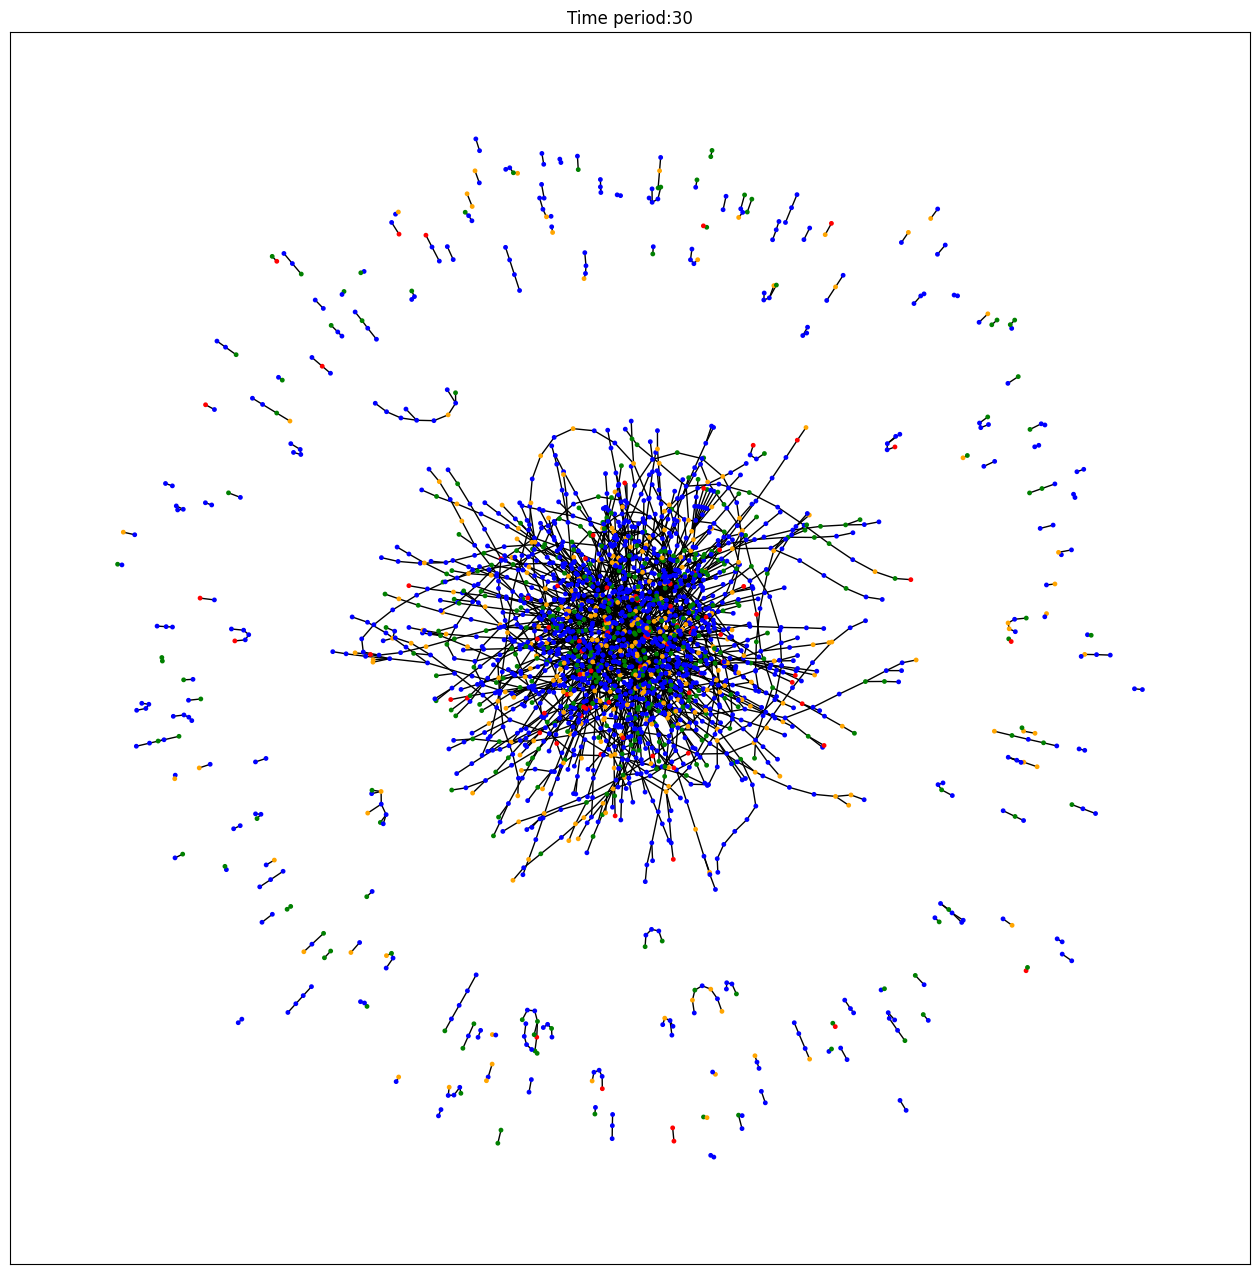

In [4]:
time_step = 30
weights_file = f"weights/{config.name}.pt"

# Khởi tạo và tải Dataset
dataset = EllipticDataset(config.dataset)
config.model.input_dim = dataset.pyg_dataset().num_node_features

# Tạo mô hình tương ứng, ví dụ ở đây config đang là của GAT
if config.train.model.upper() == "GAT":
    model = GAT(config.model)
elif config.train.model.upper() == "GCN":
    model = GCN(config.model)
elif config.train.model.upper() == "GIN":
    model = GIN(config.model)
else:
    raise ValueError(f"Model {config.train.model.upper()} chưa được hỗ trợ trong code này.")

# Load lại trọng số đã được train trước đó
model.load_state_dict(torch.load(weights_file))

# Cập nhật mô hình vào Trainer và chuyển định dạng tham số sang precision phù hợp
trainer.model = model.double().to(config.train.device)

# Tạo thư mục thư mục lưu file và xuất file kết quả
vis_dir = f"visualizations/{config.name}"
os.makedirs(vis_dir, exist_ok=True)
save_to_path = f"{vis_dir}/{time_step}.png"

try:
    trainer.visualize(dataset, time_step=time_step, save_to=save_to_path)
    print(f"\nẢnh kết quả đã được vẽ và lưu tại {save_to_path}")
    
    # Hiển thị ảnh trực tiếp lên giao diện của notebook
    from IPython.display import Image, display
    if os.path.exists(save_to_path):
        display(Image(filename=save_to_path))
except Exception as e:
    print("\nĐã xảy ra lỗi khi tạo visualization:", e)